In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from scipy import stats

df = pd.read_csv('Melbourne_housing_FULL.csv')

print('Shape:', df.shape)
print('Kolom:', df.columns.tolist())

Shape: (34857, 21)
Kolom: ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


In [2]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Pct (%)': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Pct (%)', ascending=False)
missing_df

,Column,Missing Count,Missing Pct (%)
14,BuildingArea,21115,60.58
15,YearBuilt,19306,55.39
13,Landsize,11810,33.88
12,Car,8728,25.04
11,Bathroom,8226,23.60
10,Bedroom2,8217,23.57
18,Longtitude,7976,22.88
17,Lattitude,7976,22.88
4,Price,7610,21.83
16,CouncilArea,3,0.01


In [3]:
df = df.dropna(subset=['Price'])
print('Shape setelah drop Price NaN:', df.shape)

Shape setelah drop Price NaN: (27247, 21)


In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
unique_counts = df[cat_cols].nunique().sort_values(ascending=False)
print(unique_counts)

Address        26751
SellerG          349
Suburb           345
Date              78
CouncilArea       33
Regionname         8
Method             5
Type               3
dtype: int64


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28992\505250753.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


High Cardinality -> address, seller, suburb, date, councilarea

In [5]:
baseline_cols = ['Rooms', 'Landsize', 'BuildingArea']
df_base = df[baseline_cols + ['Price']].dropna()

X_base = df_base[baseline_cols]
y_base = df_base['Price']

model_base = LinearRegression()
cv_base = cross_val_score(model_base, X_base, y_base, cv=5, scoring='r2')

print(f'CV R2 Baseline — Mean: {cv_base.mean():.4f}, Std: {cv_base.std():.4f}')

CV R2 Baseline — Mean: -0.0839, Std: 0.6164


In [6]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include='number').columns.tolist()
num_missing_pct = (df_clean[num_cols].isnull().sum() / len(df_clean) * 100).round(2)
print(num_missing_pct[num_missing_pct > 0].sort_values(ascending=False))

BuildingArea     60.89
YearBuilt        55.65
Landsize         34.00
Car              25.04
Bathroom         23.66
Bedroom2         23.64
Lattitude        22.95
Longtitude       22.95
Propertycount     0.01
dtype: float64


In [7]:
cols_impute_median = ['BuildingArea', 'YearBuilt', 'Car']
for col in cols_impute_median:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in num_cols:
    pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if pct > 20:
        df_clean = df_clean.drop(columns=[col])
        print(f'Drop kolom: {col} ({pct:.1f}% missing)')

cat_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols_clean:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print('\nTotal missing setelah penanganan:', df_clean.isnull().sum().sum())

Drop kolom: Bedroom2 (23.6% missing)
Drop kolom: Bathroom (23.7% missing)
Drop kolom: Landsize (34.0% missing)
Drop kolom: Lattitude (23.0% missing)
Drop kolom: Longtitude (23.0% missing)

Total missing setelah penanganan: 5


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28992\1025419375.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()



Kolom `BuildingArea` dipilih imputasi dengan median karena distribusinya sangat skewed ke kanan (banyak properti kecil dengan beberapa properti yang sangat besar), sehingga median lebih representatif daripada mean yang akan terpengaruh oleh nilai ekstrem. Kolom `YearBuilt` juga diimputasi dengan median karena distribusinya tidak simetris dan terdapat kemungkinan outlier pada tahun yang sangat tua, sehingga median memberikan estimasi tahun pembangunan yang lebih stabil.

In [8]:
suburb_freq = df_clean['Suburb'].value_counts()
df_clean['Suburb_freq'] = df_clean['Suburb'].map(suburb_freq)
df_clean = df_clean.drop(columns=['Suburb'])

In [9]:
seller_mean_price = df_clean.groupby('SellerG')['Price'].mean()
df_clean['SellerG_encoded'] = df_clean['SellerG'].map(seller_mean_price)
df_clean = df_clean.drop(columns=['SellerG'])

In [10]:
if 'Address' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Address'])


Kolom `Address` berisi alamat spesifik setiap properti yang bersifat unik untuk hampir setiap baris, sehingga tidak memiliki nilai prediktif yang general dan akan menyebabkan model overfit jika digunakan langsung. Encoding pada kolom dengan kardinalitas yang sangat tinggi seperti alamat rumah justru menambah noise dan dimensi tanpa memberikan informasi yang bermakna bagi model.

In [11]:
low_card_cols = [col for col in df_clean.select_dtypes(include='object').columns
                 if df_clean[col].nunique() < 15]
print('Kolom OHE:', low_card_cols)

df_clean = pd.get_dummies(df_clean, columns=low_card_cols, drop_first=True)
print('Shape setelah OHE:', df_clean.shape)

Kolom OHE: ['Type', 'Method', 'Regionname']
Shape setelah OHE: (27247, 25)


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28992\3352836151.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  low_card_cols = [col for col in df_clean.select_dtypes(include='object').columns


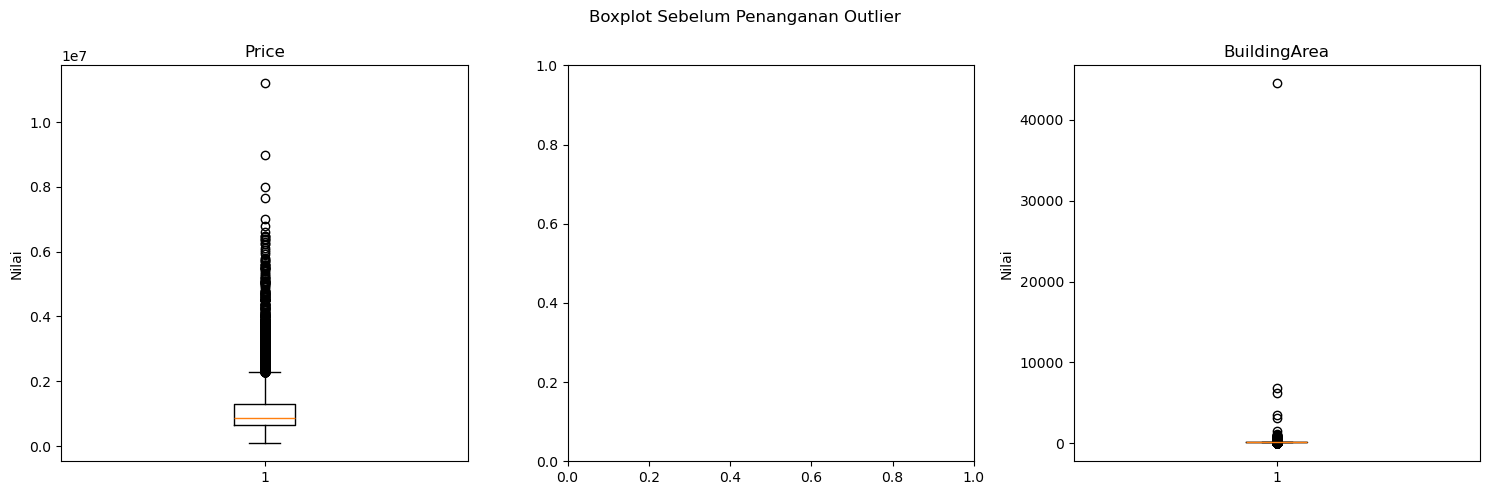

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Price', 'Landsize', 'BuildingArea']):
    if col in df_clean.columns:
        ax.boxplot(df_clean[col].dropna())
        ax.set_title(col)
        ax.set_ylabel('Nilai')

plt.suptitle('Boxplot Sebelum Penanganan Outlier')
plt.tight_layout()
plt.show()

In [13]:
Q1 = df_clean['Price'].quantile(0.25)
Q3 = df_clean['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df_clean[(df_clean['Price'] < lower_bound) | (df_clean['Price'] > upper_bound)]
print(f'Jumlah outlier Price (IQR): {len(price_outliers)}')

df_clean['Price'] = df_clean['Price'].clip(lower=lower_bound, upper=upper_bound)

Jumlah outlier Price (IQR): 1278


In [14]:
if 'Landsize' in df_clean.columns:
    z_scores = np.abs(stats.zscore(df_clean['Landsize'].dropna()))
    landsize_outliers_count = (z_scores > 3).sum()
    print(f'Jumlah outlier Landsize (Z-Score): {landsize_outliers_count}')

    # Trimming: hapus baris dengan z-score > 3
    landsize_filled = df_clean['Landsize'].dropna()
    z_full = np.abs(stats.zscore(landsize_filled))
    valid_idx = landsize_filled[z_full <= 3].index
    df_clean = df_clean.loc[df_clean.index.isin(valid_idx) | df_clean['Landsize'].isna()]

print('Shape setelah trimming Landsize:', df_clean.shape)

Shape setelah trimming Landsize: (27247, 25)


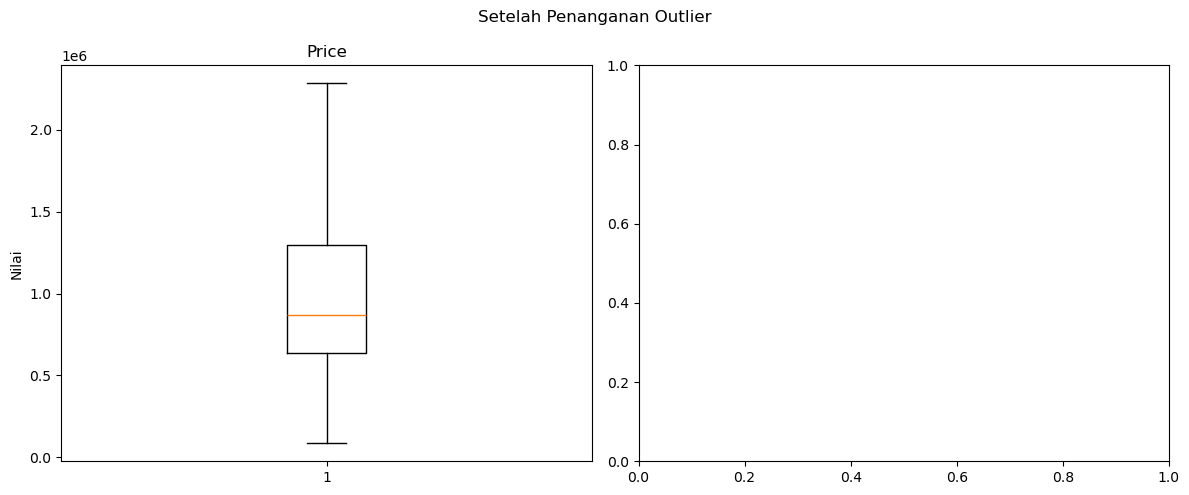

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_clean['Price'].dropna())
axes[0].set_title('Price')
axes[0].set_ylabel('Nilai')

if 'Landsize' in df_clean.columns:
    axes[1].boxplot(df_clean['Landsize'].dropna())
    axes[1].set_title('Landsize')
    axes[1].set_ylabel('Nilai')

plt.suptitle('Setelah Penanganan Outlier')
plt.tight_layout()
plt.show()

In [16]:
remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()
if remaining_cat:
    df_clean = df_clean.drop(columns=remaining_cat)

y_final = df_clean['Price']
X_final = df_clean.drop(columns=['Price']).dropna()
y_final = y_final.loc[X_final.index]

model_final = LinearRegression()
cv_final = cross_val_score(model_final, X_final, y_final, cv=5, scoring='r2')

print(f'CV R2 Final — Mean: {cv_final.mean():.4f}, Std: {cv_final.std():.4f}')

CV R2 Final — Mean: 0.6322, Std: 0.0574


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28992\3387194500.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()


Penanganan missing values dan high cardinality memberikan dampak terbesar pada skor R2 karena kedua langkah ini secara signifikan menambah jumlah fitur yang informatif, terutama melalui frequency encoding Suburb dan target encoding SellerG yang menangkap informasi lokasi dan reputasi agen secara numerik. Penanganan outlier pada Price menggunakan capping membantu model Linear Regression yang sensitif terhadap nilai ekstrem, sehingga garis regresi tidak tertarik ke arah outlier dan memberikan estimasi yang lebih akurat untuk mayoritas data. Jika ada langkah yang justru menurunkan skor, kemungkinan besar adalah trimming pada Landsize yang menghapus baris data, sehingga informasi yang hilang lebih besar dari manfaatnya bagi model linear. Ke depan, model non-linear seperti Random Forest yang lebih robust terhadap outlier dapat dipertimbangkan untuk meningkatkan performa secara keseluruhan.